In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld
from utils import paint_gridworld, get_grid

## A Look Around GridWorld

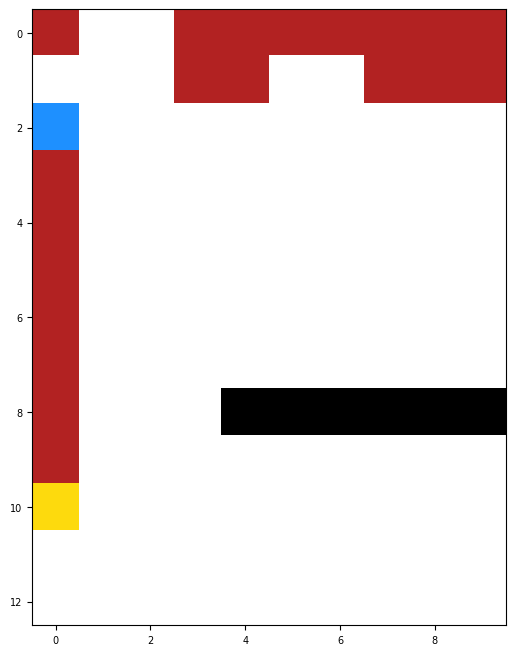

In [2]:
# Initiating the Environment. The method get_task1_gridworld
# initialises the environment for the task 1. Similarly there are methods to initialise the environment 
# for the other tasks
env1 = get_task1_gridworld()

# This is how the environment looks like
paint_gridworld(env1, figsize=(8,8), ticksize=7)

arrow_len = 0.5
def plot_directions(env, agent):
    fig, ax = plt.subplots(figsize=(8,8))
    grid = get_grid(env)
    ax.imshow(grid)
    q_values = agent.Q #Get q-values
    for state_x in range(env.get_gridshape()[0]):
        for state_y in range(env.get_gridshape()[1]):
            state_coords = [state_x, state_y]
            try:
                state_no = env._get_state_from_loc(state_coords)+1
                state = q_values[state_no-1]
                state_coords = [state_y, state_x]
                max_val = np.max(state)

                #Get number of instances of the best value
                instances = 0
                for i in state:
                    if i == max_val: 
                        instances += 1

                #Only show states with a specific preffered direction
                if instances != 1: 
                    pass

                #Draw arrows
                elif np.argmax(state) == 0:
                    plt.arrow(state_coords[0], state_coords[1]+(arrow_len/2), 0, -arrow_len, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 1:
                    plt.arrow(state_coords[0]-(arrow_len/2), state_coords[1], arrow_len, 0, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 2:
                    plt.arrow(state_coords[0], state_coords[1]-(arrow_len/2), 0, arrow_len, head_length=arrow_len/6, head_width=arrow_len/6)
                elif np.argmax(state) == 3:
                    plt.arrow(state_coords[0]+(arrow_len/2), state_coords[1], -arrow_len, 0, head_length=arrow_len/6, head_width=arrow_len/6)
            except:
                pass
        





## Example of running a simulation 

In [3]:
reward_lst = []

# Initialise the environment
# An arbitary gamma value is used here. You may need to change this!
env1 = get_task1_gridworld()

# Reset the environment to start from the starting location. 
# The reset() method returns the state, reward, and whether the episode is done or not
# More information can be found under the definition of the method
_, state, reward, done = env1.reset()
reward_lst.append(reward)

# While the trial is not done, i.e. the agent has not fallen into lava,
# the maximum length of the episode has not been exceeded, and the target has not been reached
while not done:
    
    # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
    # corresponding to ['N', 'S', 'E', 'W']
    # More information can be found under the definition of the method
    # In this very simple example for each step we choose a random action
    _, state, reward, done = env1.step(np.random.choice(4))
    reward_lst.append(reward)

print(f'Collected rewards of an episode: {reward_lst}')

Collected rewards of an episode: [0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -10.0]


In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

class Q_agent():

  def solve(self, env, policy='EPSILON', n_episodes=500, gamma=0.1, alpha=0.1, epsilon=0.1, tau=2.0):
    """
    Solve a given GridWorld environment using Q-learning
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """
    
    # Initialise your variables
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self.Q = np.zeros((self.states, self.actions))

    self._alpha = alpha #Learning Rate
    self._epsilon = epsilon #Explore Rate
    self._gamma = gamma #Discount
    self.tau = tau #Temperature

    total_steps = []
    policy_lst = []
    total_rewards = []

    for e in range(n_episodes):

      #Initialise run
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)
      while not done:

        #Determine next action
        if policy == 'EPSILON':
          action = self.epsilon_greedy_policy(state)
        elif policy == 'SOFTMAX':
          action = self.softmax_policy(state)

        _, next_state, reward, done = env.step(action)#Take action
        self.update_Q(state, action, next_state, reward) #Update Q-values
        state = next_state #Update current state

        #Record step data
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      #Record episode data
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    #Find best reward/route
    index_of_best = np.argmax(total_rewards)
    best_path = policy_lst[index_of_best]
    best_reward = total_rewards[index_of_best]
    best_path = [best_path, best_reward]

    final_path = policy_lst[len(policy_lst)-1] #Get final route

    return best_path, final_path, total_rewards, total_steps


  def update_Q(self, state, action, next_state, reward):
    #Q(s, a) ← Q(s, a) + η * [r + γ * max_a' Q(s', a') - Q(s, a)] == Q-Learning
    self.Q[state, action] += self._alpha * (reward + self._gamma*np.max(self.Q[next_state]) - self.Q[state, action])


  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)

    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4) #Explore
    else:
      return np.random.choice(optimal_actions) #Exploit

    
  def softmax_policy(self, state):
    q = self.Q[state] #Get q-values of current state
    p = np.zeros(4, dtype=np.float64)

    #Find numerator of softmax function
    for a in range(self.actions):
      n = np.e**(q[a]/self.tau)

      #Find denominator of softmax function
      d = 0
      for b in range(self.actions):
        d +=  np.e**(q[b]/self.tau)

      #Compute softmax probability
      actionProb = n/d
      p[a] = actionProb

    #Select action according to probabilities
    prob = np.random.uniform(0.0, np.sum(p))
    actionProb = 0
    for action, a in enumerate(p):
      actionProb += a
      if prob < actionProb:
        return action
    return np.random.choice(4)

In [5]:
class SARSA_agent():
  def solve(self, env, policy='EPSILON', n_episodes=500, gamma=0.1, alpha=0.1, epsilon=0.1, tau=2.0):
    """
    Solve a given GridWorld environment using SARSA
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """

    # Initialise your variables
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self.Q = np.zeros((self.states, self.actions))

    self._alpha = alpha #Learning rate
    self._gamma = gamma #Discount
    self._epsilon = epsilon #Explore rate
    self.tau = tau #Temperature

    total_steps = []
    policy_lst = []
    total_rewards = []

    for e in range(n_episodes):
      #Initialise episode
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)

      #Select first action
      if policy == 'EPSILON':
        action = self.epsilon_greedy_policy(state)
      elif policy == 'SOFTMAX':
        action = self.softmax_policy(state)

      while not done:
        _, next_state, reward, done = env.step(action) #Take selected action

        #Select action
        if policy == 'EPSILON':
          next_action = self.epsilon_greedy_policy(next_state)
        elif policy == 'SOFTMAX':
          next_action = self.softmax_policy(next_state)

        self.update_Q(state, action, next_state, next_action, reward) #Update Q-values
        state = next_state #Update current state
        action = next_action #Update current action

        #Record step data
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      #Record episode data
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    #Find best reward/route
    index_of_best = np.argmax(total_rewards)
    best_path = policy_lst[index_of_best]
    best_reward = total_rewards[index_of_best]
    best_path = [best_path, best_reward]

    final_path = policy_lst[len(policy_lst)-1] #Find final route
    
    return best_path, final_path, total_rewards, total_steps


  def update_Q(self, state, action, next_state, next_action, reward):
    #Q(s, a) ← Q(s, a) + η * [r + γ * Q(s', a') - Q(s, a)] == SARSA
    self.Q[state, action] += self._alpha * (reward + self._gamma*self.Q[next_state, next_action] - self.Q[state, action])


  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)

    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4) #Explore
    else:
      action = np.random.choice(optimal_actions) #Exploit
      return action
    
  def softmax_policy(self, state):
    q = self.Q[state] #Get q-values of current state
    p = np.zeros(4, dtype=np.float64)

    #Find numerator of softmax function
    for a in range(self.actions):
      n = np.e**(q[a]/self.tau)

      #Find denominator of softmax function
      d = 0
      for b in range(self.actions):
        d +=  np.e**(q[b]/self.tau)

      #Compute softmax probability
      actionProb = n/d
      p[a] = actionProb

    #Select action according to probabilities
    prob = np.random.uniform(0.0, np.sum(p))
    actionProb = 0
    for action, a in enumerate(p):
      actionProb += a
      if prob < actionProb:
        return action
    return np.random.choice(4)

# Task 1 - Single Target, Deterministic Rewards:

In [6]:
# Example of Hyperparameters
# This is just an example, you can add to this depending on which method you utilise

no_runs_1 = 50
no_episodes_1 = 1500

In [7]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env1 = get_task1_gridworld()

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 13
TOTAL REWARD: [-98.51564261029047, -49.12513188944017, -26.91523241282569, -22.597390768878334, 2.5173020984267773, -17.894563147261977, 2.9066892121677372, -3.7788055523594193, -9.279032029222, 33.36381536003981, -2.0336876593784434, 12.02008888904804, 12.818714588518192, 55.03480816071814, 18.769882855883594, 64.16445730019335, 41.33248043611903, 55.285385695726106, 66.56497648497178, 50.52422945422912, 28.659030779892763, 59.710895073579536, 70.4772044656754, 158.4315010401948, 96.06888213380047, 117.90758010286214, 127.8636185168724, 133.18808816226402, 98.37775775533352, 150.6297844202323, 200.06500535385032, 195.85323192195673, 246.42468084917996, 323.93125340085425, 363.4287169817547, 286.7480703293394, 394.9649120144756, 464.1589883206232, 500.85061259039645, 546.5644258262661, 544.6868757147475, 649.8607611869302, 710.2075328631009, 726.11874939

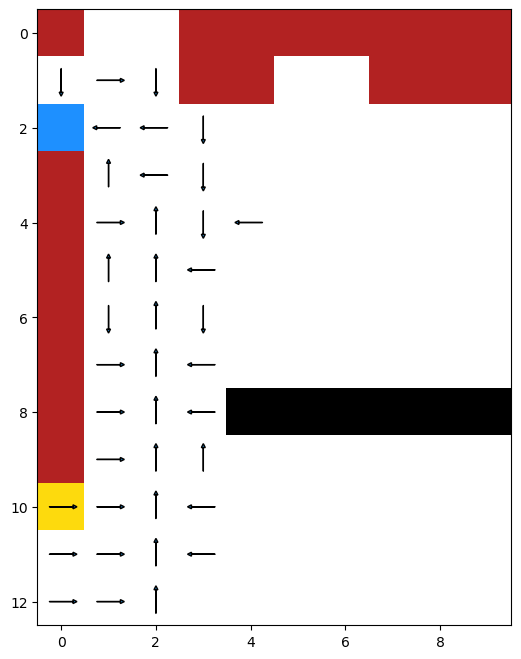

In [8]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_1 = 0.58 #Discount
s_alpha_1 = 0.27 #Learning Rate
s_epsilon_1 = 0.025 #Explore Rate
s_tau_1 = 1.5 #Temperature
policy = "EPSILON" #"EPSILON" or "SOFTMAX"

best_paths = []
best_path, final_path, sarsa_average_rewards_1, s_average_steps_1 = agent.solve(env1, policy=policy, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, tau=s_tau_1, n_episodes=no_episodes_1)
best_paths.append(best_path)

for run in range(no_runs_1-1):   
    best_path, final_path, sarsa_rewards_1, sarsa_total_steps_1 = agent.solve(env1, policy=policy, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, tau=s_tau_1, n_episodes=no_episodes_1)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_1)):
        s_average_steps_1[i] += sarsa_total_steps_1[i]
        sarsa_average_rewards_1[i] += sarsa_rewards_1[i]
for i in range(len(s_average_steps_1)):
    s_average_steps_1[i] /= no_runs_1
for i in range(len(sarsa_rewards_1)):
    sarsa_rewards_1[i] /= no_runs_1

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env1.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env1.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_average_rewards_1}")
print(f"TOTAL STEPS: {s_average_steps_1}")

plot_directions(env1, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 15
TOTAL REWARD: [-82.01133402701123, -63.61548050865891, -29.191504795028827, -19.05926612897506, -28.729293023557712, -1.9380320006212335, -3.6049468979398074, -2.3872359072339364, -3.9977528514368204, -1.3969765117047837, 1.9203355394103936, 22.167587691755262, 13.83675363721049, 32.20761572456284, 29.380461794411232, 12.648566282897496, 24.932852370846582, 67.31005761086821, 26.004723807985794, 88.02210126664484, 57.313224562094774, 66.90900131669235, 76.11181531538078, 113.81857033808589, 107.22477115964782, 120.18085425818134, 151.59893083710062, 198.56943116878733, 203.13192562219066, 129.20695999295248, 305.04443349767064, 339.9949050653228, 339.29584358773843, 408.33860452427655, 530.2769220563371, 609.0977780805517, 695.3236097173781, 674.2392090931577, 846.0578957541713, 810.0713848809916, 920.6623790737962, 1022.0756521596197, 920.6577401289861,

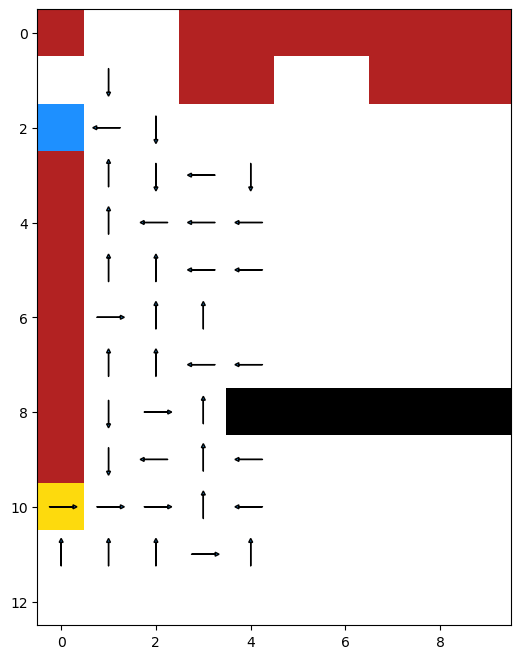

In [9]:
# Example of running Q-Learning
agent = Q_agent()

q_gamma_1 = 0.65 #Discount
q_alpha_1 = 0.175 #Learning Rate
q_epsilon_1 = 0.025 #Explore Rate
q_tau_1 = 1.5 #Temperature
policy = "EPSILON" #"EPSILON" or "SOFTMAX"

best_paths = []
best_path, final_path, q_learning_average_rewards_1, q_average_steps_1 = agent.solve(env1, policy=policy, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, tau=q_tau_1, n_episodes=no_episodes_1)
best_paths.append(best_path)

for run in range(no_runs_1-1):   
    best_path, final_path, q_learning_rewards_1, q_total_steps_1 = agent.solve(env1, policy=policy, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, tau=q_tau_1, n_episodes=no_episodes_1)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_1)):
        q_average_steps_1[i] += q_total_steps_1[i]
        q_learning_average_rewards_1[i] += q_learning_rewards_1[i]

for i in range(len(q_average_steps_1)):
    q_average_steps_1[i] /= no_runs_1
for i in range(len(q_learning_rewards_1)):
    q_learning_rewards_1[i] /= no_runs_1

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env1.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env1.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {q_learning_average_rewards_1}")
print(f"TOTAL STEPS: {q_average_steps_1}")

plot_directions(env1, agent)

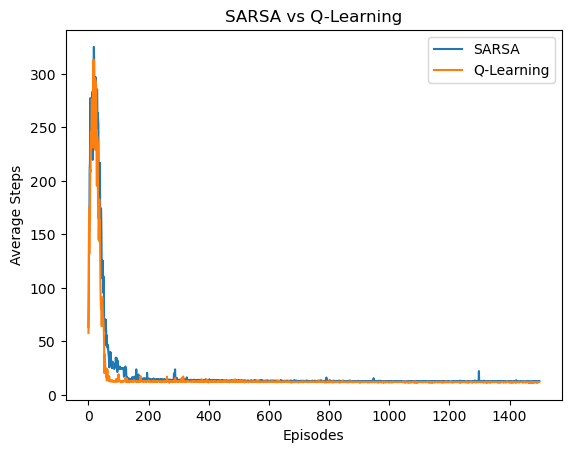

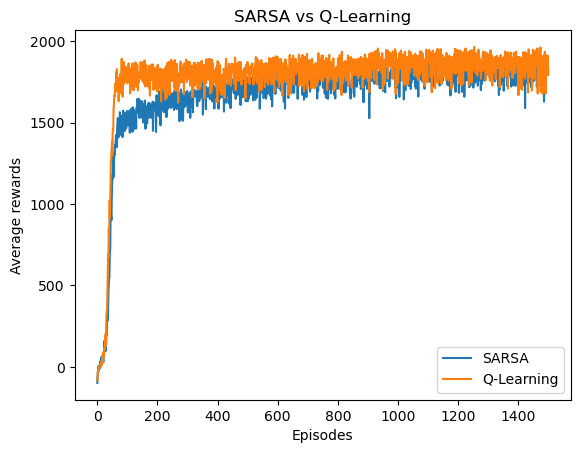

In [10]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(s_average_steps_1)
q_average = np.average(q_average_steps_1)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_average_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_average_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()


# Task 2 - Dual Targets with Stochastic Rewards

In [11]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env2 = get_task2_gridworld()
no_runs_2 = 50


STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 13
TOTAL REWARD: [-2.174333671586533, -1.2276755878268404, -0.5587889237759585, -0.31536090713232856, -0.4621632045695654, -0.5728129686974517, 0.07302925747262065, 0.06427103226458677, 0.07431052397956624, 0.05673763366799184, 0.31214911720895083, -0.023320602405031646, 1.233659153611799, 0.28274368602072286, 0.48689603349871347, 0.005509621286706243, 1.1455700182606534, 0.4190869810828171, 1.0665752671530826, 1.1778475437673999, 1.245620413612745, 1.1114403767923944, 0.2344706820466235, 1.2415554845016605, 1.6105137634992175, 1.5537339926431408, 1.2785829537509423, 1.0041964366680776, 2.0628162731782442, 1.8569568321878611, 2.755273608516475, 3.3775461962678452, 3.2664359105601153, 2.4913060554210325, 4.113951201981547, 2.5354740530424165, 1.936179996849329, 2.5084299233958904, 4.851042258116561, 5.17800507944783, 3.978777756964186, 3.3169052247214124, 4.

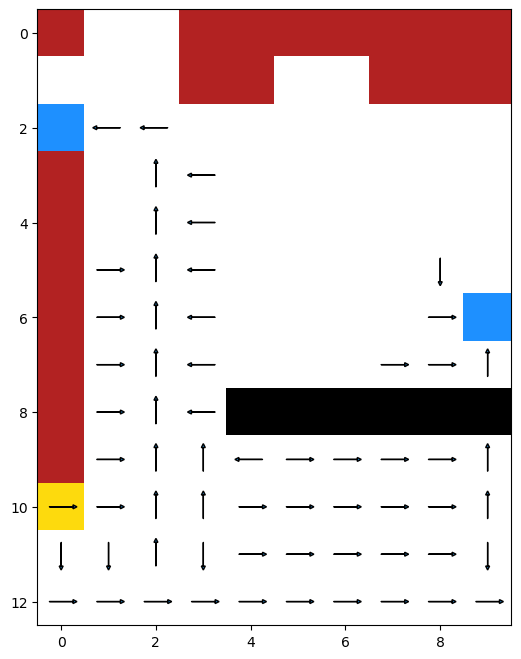

In [13]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_2 = 0.77 #Discount
s_alpha_2 = 0.2 #Learning Rate
s_epsilon_2 = 0.01 #Explore Rate
s_tau_2 = 1.2 #Softmax temperature
s_n_episodes_2 = 2500
policy = "SOFTMAX" #"EPSILON" or "SOFTMAX"

best_paths = []
best_path, final_path, sarsa_average_rewards_2, s_average_steps_2 = agent.solve(env2, policy=policy, gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=s_tau_2, n_episodes=s_n_episodes_2)
best_paths.append(best_path)

for run in range(no_runs_2-1): 
    best_path, final_path, sarsa_rewards_2, sarsa_total_steps_2 = agent.solve(env2, policy=policy, gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=s_tau_2, n_episodes=s_n_episodes_2)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_2)):
        s_average_steps_2[i] += sarsa_total_steps_2[i]
        sarsa_average_rewards_2[i] += sarsa_rewards_2[i]

for i in range(len(s_average_steps_2)):
    s_average_steps_2[i] /= no_runs_2
for i in range(len(sarsa_average_rewards_2)):
    sarsa_average_rewards_2[i] /= no_runs_2

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env2.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env2.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_average_rewards_2}")
print(f"TOTAL STEPS: {s_average_steps_2}")

plot_directions(env2, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 11
AVERAGE REWARD: [-2.1716981941376456, -0.8452622878596173, -0.9199493038722366, -0.6211711699036035, -0.6224688619824998, -0.6235048411563561, 0.02516240579450931, -0.08991591164956837, 0.37391474488272114, -0.024412247846879776, 0.27457555068400175, 0.5125918825752069, 0.001315747439148762, 0.07382914542417182, 0.24059684974098694, 0.14646398224199997, 0.3124690322960302, 1.298567104782678, 0.6013546402589551, 0.9422291438830647, 1.0440301869827309, 0.392069450944345, 1.114384573470554, 2.157111244741312, 0.6080891710824823, 1.2613341143118995, 1.8257199714283403, 1.0164998106415355, 2.7911770805429046, 1.620335866857442, 3.106135487972054, 2.831037255868626, 2.7991061802286703, 3.162628540011353, 4.821008204595632, 2.7426433633949507, 1.8600697032887483, 2.7132396609368277, 4.239158383294187, 4.5304916299936435, 3.6647565168344713, 4.537067331720175, 2

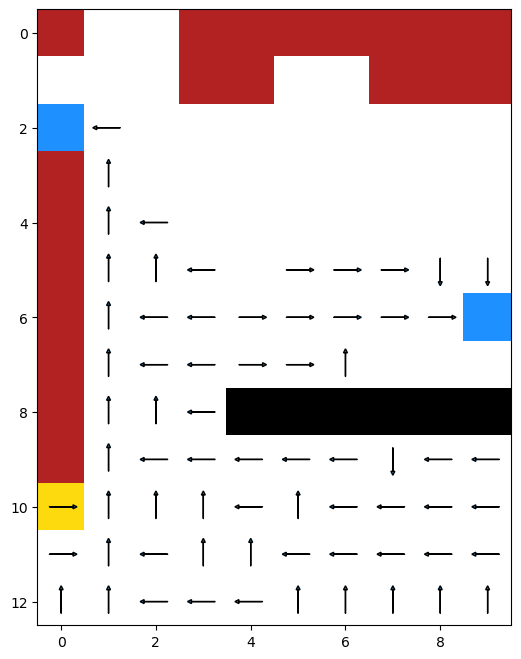

In [ ]:
# Example of running Q-Learning
q_gamma_2 = 0.64 #Discount
q_alpha_2 = 0.15 #Learning Rate
q_epsilon_2 = 0.05 #Explore Rate
q_tau_2 = 1.25 #Temperature
q_n_episodes_2 = 2500
policy = "SOFTMAX" #"EPSILON" or "SOFTMAX"

agent = Q_agent()
best_paths = []
best_path, final_path, q_average_rewards_2, q_average_steps_2 = agent.solve(env2, policy=policy, gamma=q_gamma_2, alpha=q_alpha_2, epsilon=q_epsilon_2, tau=q_tau_2, n_episodes=q_n_episodes_2)
best_paths.append(best_path)

for run in range(no_runs_2-1): 
    best_path, final_path, q_rewards_2, q_total_steps_2 = agent.solve(env2, policy=policy, gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, tau=q_tau_2, n_episodes=s_n_episodes_2)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_2)):
        q_average_steps_2[i] += q_total_steps_2[i]
        q_average_rewards_2[i] += q_rewards_2[i]
        
for i in range(len(q_average_steps_2)):
    q_average_steps_2[i] /= no_runs_2
for i in range(len(q_average_rewards_2)):
    q_average_rewards_2[i] /= no_runs_2

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env2.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env2.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"AVERAGE REWARD: {q_average_rewards_2}")
print(f"AVERAGE STEPS: {q_average_steps_2}")

plot_directions(env2, agent)

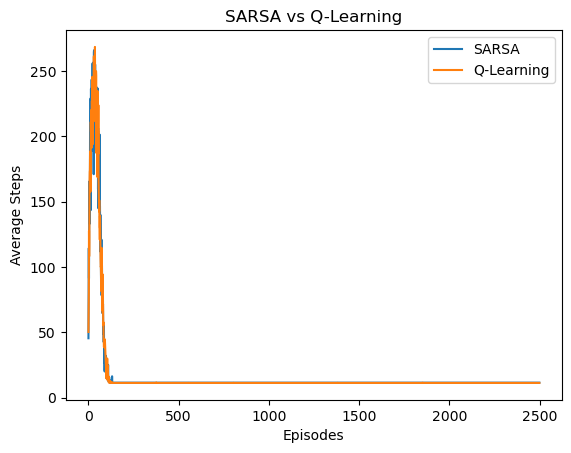

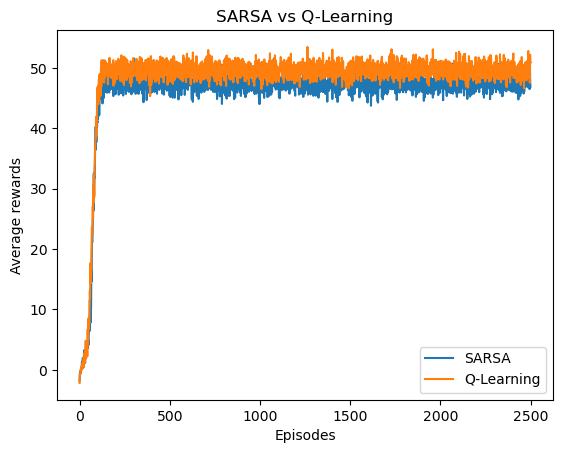

In [ ]:
# Do your plots below! Include any new function definitions in this jupyter notebook!

sarsa_average = np.average(s_average_steps_2)
q_average = np.average(q_average_steps_2)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 3 - Stochastic Transitions and Rewards

In [ ]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env3 = get_task3_gridworld()
no_episodes_3 = 3000
no_runs_3 = 50

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 23
TOTAL REWARD: [-1.4352547280187387, -1.7097012533463805, -1.2887145748308635, -1.9497174083051165, -2.143181520926133, -1.5428608636603327, -1.3653663260531557, -1.8584617878676224, -1.0436541302767166, -1.152516569860628, -1.4747024670808486, -1.1637515578489561, -2.0151997159113155, -0.8502933930347631, -1.1156233135002713, -1.2991719505103223, -1.3211970651177445, -0.48535099228888307, -1.5053183058127613, -1.4269662967500096, -1.0469918200074275, -1.2695231402827498, -1.085119742319898, -0.25330697976405675, -0.7514125255691492, -0.9048015452620162, -1.0131017256178525, -0.9049817650424115, -0.8476769033847232, -0.7241047919227591, -0.6153050345582034, -1.0112899326737839, -1.2897550289528001, -1.3226059180770984, -0.7768754077375671, -1.1000531680036083, -0.031168132480975084, -1.3609340228935474, -0.44334317246335914, -1.5534987385583126, -1.109348

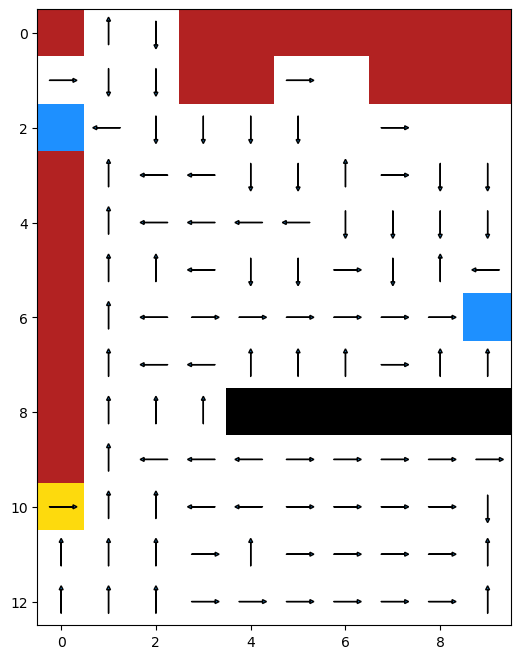

In [ ]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_3 = 0.95 #Discount
s_alpha_3 = 0.04 #Learning Rate
s_epsilon_3 = 0.03 #Explore Rate
s_tau_3 = 1.2 #Tempature
policy = "SOFTMAX" #"EPSILON" or "SOFTMAX"

best_paths = []
best_path, final_path, sarsa_average_rewards_3, s_average_steps_3 = agent.solve(env3, policy=policy, gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=s_tau_3, n_episodes=no_episodes_3)
best_paths.append(best_path)

for run in range(no_runs_3-1):   
    best_path, final_path, sarsa_rewards_3, sarsa_total_steps_3 = agent.solve(env3, policy=policy, gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=s_tau_3, n_episodes=no_episodes_3)
    best_paths.append(best_path)
    for i in range(len(s_average_steps_3)):
        s_average_steps_3[i] += sarsa_total_steps_3[i]
        sarsa_average_rewards_3[i] += sarsa_rewards_3[i]
for i in range(len(s_average_steps_3)):
    s_average_steps_3[i] /= no_runs_3
for i in range(len(sarsa_average_rewards_3)):
    sarsa_average_rewards_3[i] /= no_runs_3

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env3.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env3.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"TOTAL REWARD: {sarsa_average_rewards_3}")
print(f"TOTAL STEPS: {s_average_steps_3}")

plot_directions(env3, agent)

STRATEGY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
Best Length: 11
Final Length: 15
AVERAGE REWARD: [-1.9736458189335224, -1.396840572915825, -1.8485820132905042, -1.3736368295753303, -1.5113391621065093, -0.6971203806332191, -1.2893645839052834, -1.3825701757083706, -1.2517311124789936, -0.9152931567887265, -1.182227538686301, -1.1120057071166896, -1.394470571581324, -1.4217146383332544, -1.038612870803763, -0.9705077723943412, -1.161139602249947, -1.1117883006458609, -1.0441005867198303, -1.0483851548432992, -0.5891865941734035, -1.0217515415586151, -0.607699024325222, -1.093392289220429, -0.8152972199820784, -0.5798945417476395, -0.6260320538805508, -1.1997688161374167, -0.4882693897525522, -0.9163707022476566, -0.7413545080222164, -0.9736323121004961, -0.744207394841303, -0.5707646330038191, -0.9505712788965763, -0.8072140819970862, -0.979648383820156, -0.8198310030894258, -0.50718085222923, -1.2247295296305287, -1.0496278411028315,

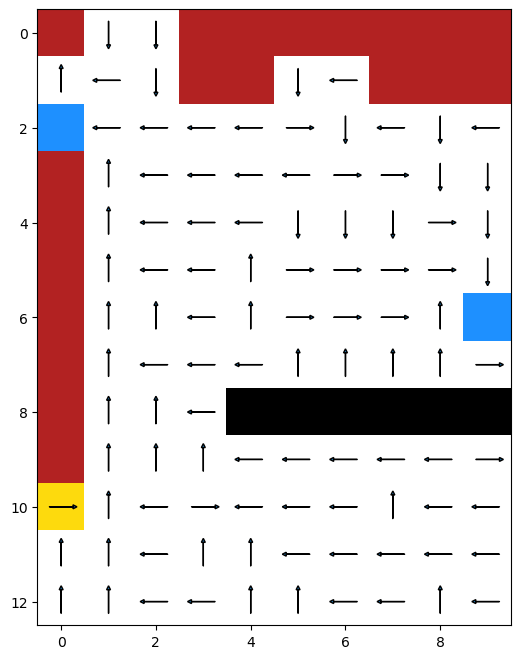

In [ ]:
# Example of running Q-Learning
q_gamma_3 = 0.82 #Discount
q_alpha_3 = 0.08 #Learning Rate
q_epsilon_3 = 0.08 #Explore Rate
q_tau_3 = 1.2 #Temperature
policy = "SOFTMAX" #"EPSILON" or "SOFTMAX"

agent = Q_agent()
best_paths = []
best_path, final_path, q_average_rewards_3, q_average_steps_3 = agent.solve(env3, policy=policy, gamma=q_gamma_3, alpha=q_alpha_3, epsilon=q_epsilon_3, tau=q_tau_3, n_episodes=no_episodes_3)
best_paths.append(best_path)

for run in range(no_runs_3-1): 
    best_path, final_path, q_rewards_3, q_total_steps_3 = agent.solve(env3, policy=policy, gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, tau=q_tau_3, n_episodes=no_episodes_3)
    best_paths.append(best_path)
    for i in range(len(q_average_steps_3)):
        q_average_steps_3[i] += q_total_steps_3[i]
        q_average_rewards_3[i] += q_rewards_3[i]
        
for i in range(len(q_average_steps_3)):
    q_average_steps_3[i] /= no_runs_3
for i in range(len(q_average_rewards_3)):
    q_average_rewards_3[i] /= no_runs_3

for path in best_paths:
    if path[1] > best_path[1]:
        best_path = path
best_path = best_path[0]

loc_best = []
for i in range(len(best_path)):
    loc_best.append(env3.get_loc_from_state(best_path[i]))
loc_final = []
for i in range(len(final_path)):
    loc_final.append(env3.get_loc_from_state(final_path[i]))

print(f"STRATEGY: {loc_best}")
print(f"Best Length: {len(loc_best)}")
print(f"Final Length: {len(loc_final)}")
print(f"AVERAGE REWARD: {q_average_rewards_3}")
print(f"AVERAGE STEPS: {q_average_steps_3}")

plot_directions(env3, agent)

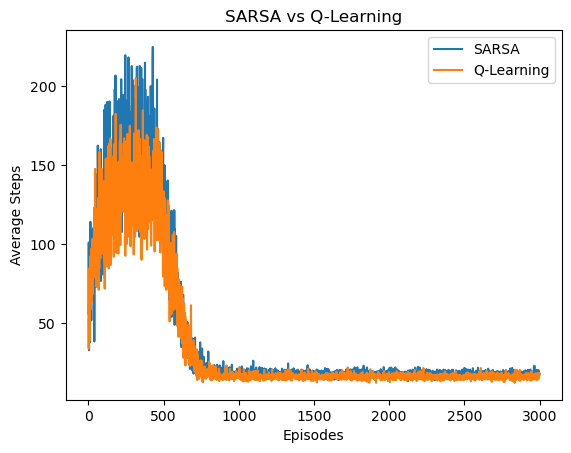

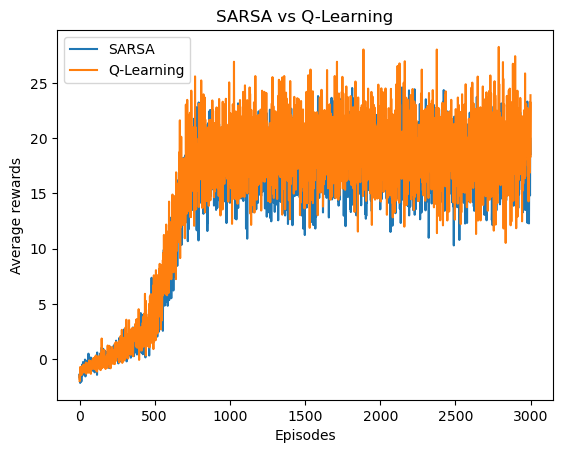

In [ ]:
# Do your plots below! Include any new function definitions in this jupyter notebook!

sarsa_average = np.average(s_average_steps_3)
q_average = np.average(q_average_steps_3)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(s_average_steps_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_steps_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_steps_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(s_average_steps_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Steps')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_average_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_average_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_average_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_average_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average rewards')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()